### **State University of Campinas - UNICAMP** </br>
**Course**: MC886A </br>
**Professor**: Marcelo da Silva Reis </br>
**TA (PED)**: Marcos Vinicius Souza Freire

---

**Student 1**: Henry Koiti Honda

**RA 1**: 258141

**Student 2**: Diego Pires Silva

**RA 2**:239489

In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from torchmetrics import Accuracy, F1Score, Precision, Recall
from PIL import Image
from tqdm import tqdm

from torchcam.methods import GradCAM
from torchcam.utils import overlay_mask

In [37]:
import os
from pathlib import Path
from PIL import Image
import numpy as np
import pandas as pd
from tqdm import tqdm

print("--- Início do Script de Pré-processamento para Gerar CSVs de Rótulos ---")


base_path_atividade = Path(r'C:\Users\rseit\OneDrive\Área de Trabalho\Atividade_3')

image_base_dir = base_path_atividade / 'DOWNSTREAM_(image)'
annotation_base_dir = base_path_atividade / 'DOWNSTREAM_(annotation)'

splits_config = {
    'D_TRAIN': 'train_labels.csv',
    'D_VALIDATION': 'val_labels.csv',
    'D_TEST': 'test_labels.csv'
}

output_csv_dir = base_path_atividade / 'processed_labels_csv'
os.makedirs(output_csv_dir, exist_ok=True)

print(f"\nDiretório base da atividade configurado para: {base_path_atividade.resolve()}")
if not image_base_dir.exists() or not annotation_base_dir.exists():
    print(f"ERRO FATAL: Diretórios base de dados não encontrados.")
    print(f"Verifique se '{image_base_dir.name}' (em {image_base_dir.resolve()})")
    print(f"e '{annotation_base_dir.name}' (em {annotation_base_dir.resolve()}) existem.")
    exit()
else:
    print(f"Diretório de imagens base encontrado: {image_base_dir.resolve()}")
    print(f"Diretório de anotações base encontrado: {annotation_base_dir.resolve()}")
    print(f"CSVs de saída serão salvos em: {output_csv_dir.resolve()}")
    print("-" * 70)

for split_folder_name, csv_filename in splits_config.items():
    print(f"\nProcessando o split: '{split_folder_name}'...")

    current_image_folder = image_base_dir / split_folder_name
    current_annotation_folder = annotation_base_dir / split_folder_name
    output_csv_file_path = output_csv_dir / csv_filename

    if not current_image_folder.exists():
        print(f"  AVISO: Pasta de imagens para o split '{split_folder_name}' NÃO ENCONTRADA em: {current_image_folder.resolve()}. Pulando este split.")
        print("-" * 70)
        continue
    if not current_annotation_folder.exists():
        print(f"  AVISO: Pasta de anotações para o split '{split_folder_name}' NÃO ENCONTRADA em: {current_annotation_folder.resolve()}. Pulando este split.")
        print("-" * 70)
        continue

    try:
        image_filenames = sorted([
            f for f in os.listdir(current_image_folder)
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp'))
        ])
    except FileNotFoundError:
        print(f"  ERRO ao listar arquivos em {current_image_folder.resolve()}. Verifique se o caminho é uma pasta válida. Pulando este split.")
        print("-" * 70)
        continue
        
    if not image_filenames:
        print(f"  AVISO: Nenhuma imagem encontrada em {current_image_folder.resolve()} para o split '{split_folder_name}'. Pulando este split.")
        print("-" * 70)
        continue

    print(f"  Encontradas {len(image_filenames)} imagens em '{current_image_folder.name}'. Iniciando derivação de rótulos...")
    
    data_for_dataframe = []
    
    for img_name in tqdm(image_filenames, desc=f"  Analisando máscaras em '{split_folder_name}'"):
        full_image_path = current_image_folder / img_name
        corresponding_mask_path = current_annotation_folder / img_name

        derived_label = -1
        try:
            mask_image = Image.open(corresponding_mask_path).convert('L')
            mask_array = np.array(mask_image)
            
            if np.any(mask_array == 1):
                derived_label = 1
            else:
                derived_label = 0
                
        except FileNotFoundError:
            tqdm.write(f"    AVISO: Máscara '{corresponding_mask_path.name}' NÃO ENCONTRADA para a imagem '{img_name}'. Imagem ignorada.")
            continue
        except Exception as e:
            tqdm.write(f"    ERRO ao processar máscara '{corresponding_mask_path.name}': {e}. Imagem ignorada.")
            continue
        
        data_for_dataframe.append({
            'image_path': str(full_image_path.resolve()),
            'derived_label': derived_label
        })
            
    if not data_for_dataframe:
        print(f"  Nenhum dado processado com sucesso para o split '{split_folder_name}'. Um CSV vazio será criado.")
        labels_df = pd.DataFrame(columns=['image_path', 'derived_label'])
    else:
        labels_df = pd.DataFrame(data_for_dataframe)
        
    labels_df.to_csv(output_csv_file_path, index=False)
    print(f"  Rótulos para '{split_folder_name}' salvos em: {output_csv_file_path.resolve()} ({len(labels_df)} entradas).")
    
    if not labels_df.empty:
        print(f"  Distribuição dos rótulos no CSV '{csv_filename}':")
        print(labels_df['derived_label'].value_counts(dropna=False).to_string())
    else:
        print(f"  CSV '{csv_filename}' está vazio. Nenhuma distribuição para mostrar.")
    print("-" * 70)

print("\n--- Fim do Script de Pré-processamento ---")
print(f"Verifique a pasta: {output_csv_dir.resolve()} pelos arquivos CSV gerados.")

--- Início do Script de Pré-processamento para Gerar CSVs de Rótulos ---

Diretório base da atividade configurado para: C:\Users\rseit\OneDrive\Área de Trabalho\Atividade_3
Diretório de imagens base encontrado: C:\Users\rseit\OneDrive\Área de Trabalho\Atividade_3\DOWNSTREAM_(image)
Diretório de anotações base encontrado: C:\Users\rseit\OneDrive\Área de Trabalho\Atividade_3\DOWNSTREAM_(annotation)
CSVs de saída serão salvos em: C:\Users\rseit\OneDrive\Área de Trabalho\Atividade_3\processed_labels_csv
----------------------------------------------------------------------

Processando o split: 'D_TRAIN'...
  Encontradas 630 imagens em 'D_TRAIN'. Iniciando derivação de rótulos...


  Analisando máscaras em 'D_TRAIN':   0%|          | 0/630 [00:00<?, ?it/s]

  Analisando máscaras em 'D_TRAIN': 100%|██████████| 630/630 [00:01<00:00, 550.89it/s]


  Rótulos para 'D_TRAIN' salvos em: C:\Users\rseit\OneDrive\Área de Trabalho\Atividade_3\processed_labels_csv\train_labels.csv (630 entradas).
  Distribuição dos rótulos no CSV 'train_labels.csv':
derived_label
1    630
----------------------------------------------------------------------

Processando o split: 'D_VALIDATION'...
  Encontradas 168 imagens em 'D_VALIDATION'. Iniciando derivação de rótulos...


  Analisando máscaras em 'D_VALIDATION': 100%|██████████| 168/168 [00:00<00:00, 629.29it/s]


  Rótulos para 'D_VALIDATION' salvos em: C:\Users\rseit\OneDrive\Área de Trabalho\Atividade_3\processed_labels_csv\val_labels.csv (168 entradas).
  Distribuição dos rótulos no CSV 'val_labels.csv':
derived_label
1    168
----------------------------------------------------------------------

Processando o split: 'D_TEST'...
  Encontradas 168 imagens em 'D_TEST'. Iniciando derivação de rótulos...


  Analisando máscaras em 'D_TEST': 100%|██████████| 168/168 [00:00<00:00, 679.19it/s]

  Rótulos para 'D_TEST' salvos em: C:\Users\rseit\OneDrive\Área de Trabalho\Atividade_3\processed_labels_csv\test_labels.csv (168 entradas).
  Distribuição dos rótulos no CSV 'test_labels.csv':
derived_label
1    168
----------------------------------------------------------------------

--- Fim do Script de Pré-processamento ---
Verifique a pasta: C:\Users\rseit\OneDrive\Área de Trabalho\Atividade_3\processed_labels_csv pelos arquivos CSV gerados.


In [38]:
base_path_atividade = Path(r'C:\Users\rseit\OneDrive\Área de Trabalho\Atividade_3')

csv_dir = base_path_atividade / 'processed_labels_csv'

TRAIN_CSV_PATH = csv_dir / 'train_labels.csv'
VAL_CSV_PATH = csv_dir / 'val_labels.csv'
TEST_CSV_PATH = csv_dir / 'test_labels.csv'

csv_files_exist = True
for csv_p in [TRAIN_CSV_PATH, VAL_CSV_PATH, TEST_CSV_PATH]:
    if not csv_p.exists():
        print(f"ERRO: Arquivo CSV '{csv_p.name}' não encontrado em '{csv_dir.resolve()}'.")
        print("Certifique-se de que o script 'gerar_csv_rotulos.py' foi executado com sucesso.")
        csv_files_exist = False
        break

if csv_files_exist:
    print(f"Arquivos CSV de rótulos encontrados em: {csv_dir.resolve()}")
else:
    print("Um ou mais arquivos CSV não foram encontrados. As próximas células podem falhar.")

Arquivos CSV de rótulos encontrados em: C:\Users\rseit\OneDrive\Área de Trabalho\Atividade_3\processed_labels_csv


DataFrames carregados dos CSVs com sucesso!

--- Análise da Distribuição das Classes ---

Conjunto de Treino:
derived_label
1    630
Name: count, dtype: int64


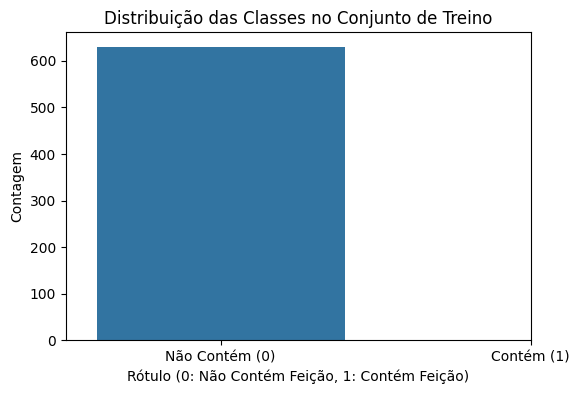


Conjunto de Validação:
derived_label
1    168
Name: count, dtype: int64

Conjunto de Teste:
derived_label
1    168
Name: count, dtype: int64

Pesos das classes não calculados (dataset de treino vazio, não binário, ou coluna 'derived_label' ausente).


In [39]:
train_df = pd.DataFrame()
val_df = pd.DataFrame()
test_df = pd.DataFrame()

if csv_files_exist:
    try:
        train_df = pd.read_csv(TRAIN_CSV_PATH)
        val_df = pd.read_csv(VAL_CSV_PATH)
        test_df = pd.read_csv(TEST_CSV_PATH)
        print("DataFrames carregados dos CSVs com sucesso!")
    except Exception as e:
        print(f"Erro ao carregar um ou mais arquivos CSV: {e}")
        print("Verifique se os arquivos CSV não estão corrompidos ou vazios inesperadamente.")
        csv_files_exist = False

print("\n--- Análise da Distribuição das Classes ---")

if not train_df.empty:
    print("\nConjunto de Treino:")
    print(train_df['derived_label'].value_counts(dropna=False))
    
    plt.figure(figsize=(6, 4))
    sns.countplot(x='derived_label', data=train_df)
    plt.title('Distribuição das Classes no Conjunto de Treino')
    plt.xlabel('Rótulo (0: Não Contém Feição, 1: Contém Feição)')
    plt.ylabel('Contagem')
    plt.xticks([0, 1], ['Não Contém (0)', 'Contém (1)'])
    plt.show()
else:
    print("\nDataFrame de treino vazio ou não carregado. Não é possível analisar a distribuição.")

if not val_df.empty:
    print("\nConjunto de Validação:")
    print(val_df['derived_label'].value_counts(dropna=False))
else:
    print("\nDataFrame de validação vazio ou não carregado.")

if not test_df.empty:
    print("\nConjunto de Teste:")
    print(test_df['derived_label'].value_counts(dropna=False))
else:
    print("\nDataFrame de teste vazio ou não carregado.")

class_weights = None
if not train_df.empty and 'derived_label' in train_df.columns and len(train_df['derived_label'].unique()) >=2 :
    counts = train_df['derived_label'].value_counts()
    if 0 in counts and 1 in counts :
        weight_for_0 = len(train_df) / (2 * counts.get(0, 1e-6)) 
        weight_for_1 = len(train_df) / (2 * counts.get(1, 1e-6))
        class_weights = torch.tensor([weight_for_0, weight_for_1], dtype=torch.float32)
        print(f"\nPesos calculados para as classes (0 e 1) no treino: {class_weights.numpy()}")
    else:
        print("\nPesos das classes não calculados: Uma ou ambas as classes (0, 1) não estão presentes no conjunto de treino.")
else:
    print("\nPesos das classes não calculados (dataset de treino vazio, não binário, ou coluna 'derived_label' ausente).")

In [40]:
print("\n--- Análise das Dimensões das Imagens (Amostra) ---")

def get_image_dimensions(image_path_str):
    try:
        with Image.open(image_path_str) as img:
            return img.size
    except FileNotFoundError:
        return None
    except Exception as e:
        return None

if not train_df.empty and 'image_path' in train_df.columns:
    num_samples_to_check = min(5, len(train_df))
    print(f"Verificando dimensões de {num_samples_to_check} imagens do conjunto de treino:")
    found_dimensions_count = 0
    for i in range(len(train_df)):
        if found_dimensions_count >= num_samples_to_check:
            break
        img_path = train_df.loc[i, 'image_path']
        if pd.isna(img_path):
            continue
        dimensions = get_image_dimensions(img_path)
        if dimensions:
            print(f"  Imagem: {Path(img_path).name}, Dimensões Originais (Largura, Altura): {dimensions}")
            found_dimensions_count += 1
    if found_dimensions_count == 0:
        print("  Nenhuma dimensão de imagem pôde ser lida das amostras verificadas.")
else:
    print("Não é possível verificar dimensões: DataFrame de treino vazio ou coluna 'image_path' ausente.")


--- Análise das Dimensões das Imagens (Amostra) ---
Verificando dimensões de 5 imagens do conjunto de treino:
  Imagem: AA1.png, Dimensões Originais (Largura, Altura): (720, 340)
  Imagem: AA10.png, Dimensões Originais (Largura, Altura): (720, 340)
  Imagem: AA100.png, Dimensões Originais (Largura, Altura): (720, 340)
  Imagem: AA101.png, Dimensões Originais (Largura, Altura): (720, 340)
  Imagem: AA102.png, Dimensões Originais (Largura, Altura): (720, 340)


In [41]:
print("\n--- Definindo Transformações de Pré-processamento ---")

IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Transformações definidas.")


--- Definindo Transformações de Pré-processamento ---
Transformações definidas.


In [42]:
print("\n--- Definindo Classe Dataset e Criando DataLoaders ---")

class GPRClassificationDataset(Dataset):
    def __init__(self, csv_file_path, transform=None):
        self.transform = transform
        try:
            self.data_frame = pd.read_csv(csv_file_path)
            if self.data_frame.empty and Path(csv_file_path).exists():
                print(f"AVISO: O arquivo CSV {csv_file_path} foi carregado mas está vazio.")
            elif not self.data_frame.empty:
                 print(f"Dataset carregado de {Path(csv_file_path).name}: {len(self.data_frame)} amostras.")
        except FileNotFoundError:
            print(f"ERRO CRÍTICO: Arquivo CSV não encontrado em {csv_file_path}.")
            self.data_frame = pd.DataFrame(columns=['image_path', 'derived_label'])
        except pd.errors.EmptyDataError:
            print(f"ERRO CRÍTICO: Arquivo CSV {csv_file_path} está vazio ou mal formatado.")
            self.data_frame = pd.DataFrame(columns=['image_path', 'derived_label'])
        except Exception as e:
            print(f"ERRO CRÍTICO ao carregar {csv_file_path}: {e}")
            self.data_frame = pd.DataFrame(columns=['image_path', 'derived_label'])

    def __len__(self):
        return len(self.data_frame)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        dummy_image_tensor = torch.zeros((3, IMG_SIZE, IMG_SIZE)) 
        dummy_label_tensor = torch.tensor(-1, dtype=torch.long)

        if self.data_frame.empty or not (0 <= idx < len(self.data_frame)):
            return dummy_image_tensor, dummy_label_tensor

        try:
            img_path_str = self.data_frame.loc[idx, 'image_path']
            label_val = self.data_frame.loc[idx, 'derived_label']
        except KeyError as e:
            return dummy_image_tensor, dummy_label_tensor
        except IndexError:
            return dummy_image_tensor, dummy_label_tensor


        if pd.isna(img_path_str) or not isinstance(img_path_str, str):
            return dummy_image_tensor, torch.tensor(int(label_val) if pd.notna(label_val) else -1, dtype=torch.long)

        try:
            image = Image.open(img_path_str).convert('RGB')
        except FileNotFoundError:
            return dummy_image_tensor, torch.tensor(int(label_val), dtype=torch.long)
        except Exception as e:
            return dummy_image_tensor, torch.tensor(int(label_val), dtype=torch.long)

        label = torch.tensor(int(label_val), dtype=torch.long)

        if self.transform:
            try:
                image = self.transform(image)
            except Exception as e:
                image = transforms.ToTensor()(image) if isinstance(image, Image.Image) else dummy_image_tensor
        
        return image, label

train_dataset = GPRClassificationDataset(csv_file_path=TRAIN_CSV_PATH, transform=train_transform)
val_dataset = GPRClassificationDataset(csv_file_path=VAL_CSV_PATH, transform=val_test_transform)
test_dataset = GPRClassificationDataset(csv_file_path=TEST_CSV_PATH, transform=val_test_transform)

BATCH_SIZE = 16
NUM_WORKERS = 0

train_loader, val_loader, test_loader = None, None, None

if len(train_dataset) > 0 and not train_dataset.data_frame.empty:
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True if NUM_WORKERS > 0 else False)
else:
    print("AVISO: train_dataset está vazio. train_loader não foi criado.")

if len(val_dataset) > 0 and not val_dataset.data_frame.empty:
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True if NUM_WORKERS > 0 else False)
else:
    print("AVISO: val_dataset está vazio. val_loader não foi criado.")

if len(test_dataset) > 0 and not test_dataset.data_frame.empty:
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True if NUM_WORKERS > 0 else False)
else:
    print("AVISO: test_dataset está vazio. test_loader não foi criado.")

print(f"\nStatus dos DataLoaders:")
print(f"  Train Loader: {'Criado' if train_loader else 'NÃO CRIADO (Dataset vazio ou erro)'}")
print(f"  Val Loader:   {'Criado' if val_loader else 'NÃO CRIADO (Dataset vazio ou erro)'}")
print(f"  Test Loader:  {'Criado' if test_loader else 'NÃO CRIADO (Dataset vazio ou erro)'}")


--- Definindo Classe Dataset e Criando DataLoaders ---
Dataset carregado de train_labels.csv: 630 amostras.
Dataset carregado de val_labels.csv: 168 amostras.
Dataset carregado de test_labels.csv: 168 amostras.

Status dos DataLoaders:
  Train Loader: Criado
  Val Loader:   Criado
  Test Loader:  Criado



--- Visualizando Amostras do DataLoader de Treino ---


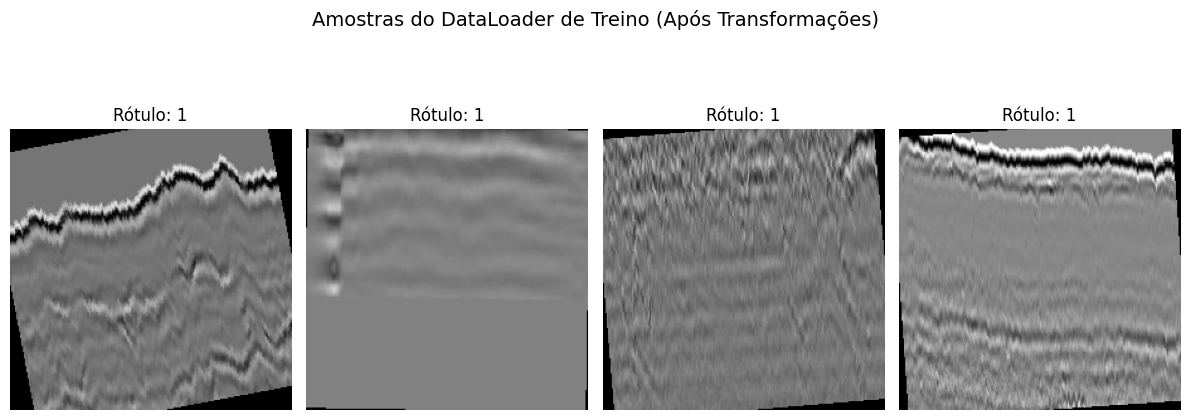

In [43]:
print("\n--- Visualizando Amostras do DataLoader de Treino ---")

def imshow(tensor_img, title=None, denormalize=True):
    img_display = tensor_img.cpu().clone()
    if denormalize:
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        for t, m, s in zip(img_display, mean, std):
            t.mul_(s).add_(m)
    img_display = img_display.numpy().transpose((1, 2, 0))
    img_display = np.clip(img_display, 0, 1)
    
    plt.imshow(img_display)
    if title:
        plt.title(title)
    plt.axis('off')

if train_loader:
    try:
        dataiter = iter(train_loader)
        images, labels = next(dataiter)

        num_images_to_show = min(4, len(images))
        if num_images_to_show > 0 :
            plt.figure(figsize=(12, num_images_to_show * 1.2))
            for i in range(num_images_to_show):
                plt.subplot(1, num_images_to_show, i+1)
                imshow(images[i], title=f"Rótulo: {labels[i].item()}")
            plt.suptitle("Amostras do DataLoader de Treino (Após Transformações)", fontsize=14)
            plt.tight_layout(rect=[0, 0, 1, 0.95])
            plt.show()
        else:
            print("Nenhuma imagem para mostrar no batch obtido do train_loader (batch pode ser menor que o esperado ou vazio).")

    except StopIteration:
        print("Não foi possível obter um batch do train_loader. Verifique se o DataLoader e o Dataset subjacente não estão vazios.")
    except Exception as e:
        print(f"Ocorreu um erro ao tentar visualizar amostras do train_loader: {e}")
        print("Isso pode ser devido a um problema no __getitem__ do Dataset ou no próprio DataLoader.")
else:
    print("train_loader não foi criado ou está indisponível. Não é possível visualizar amostras.")

In [44]:
print("\n--- Definindo Arquiteturas dos Modelos CNN ---")

if 'device' not in globals():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Dispositivo de fallback definido para: {device}")


NUM_CLASSES = 2

def get_resnet50_baseline(num_classes=NUM_CLASSES, pretrained=True):
    if pretrained:
        weights = models.ResNet50_Weights.IMAGENET1K_V1
    else:
        weights = None
        
    model = models.resnet50(weights=weights)
    
    if pretrained:
        for param in model.parameters():
            param.requires_grad = False
            
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    
    for param in model.fc.parameters():
        param.requires_grad = True
        
    return model

print("Modelo Baseline (ResNet50) definido.")

def init_weights_he(m):
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)


class SimpleCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super(SimpleCNN, self).__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, stride=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) 
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1, stride=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * (IMG_SIZE // 4) * (IMG_SIZE // 4), 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
        self.apply(init_weights_he)

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.classifier(x)
        return x

print("Custom Model 1 (SimpleCNN) definido.")

class ModerateCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super(ModerateCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25),

            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25),

            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2) 
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * (IMG_SIZE // 8) * (IMG_SIZE // 8), 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
        self.apply(init_weights_he)

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

print("Custom Model 2 (ModerateCNN) definido.")


class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += identity
        out = self.relu(out)
        return out

class AdvancedCNN(nn.Module):
    def __init__(self, block_class, num_blocks_list, num_classes=NUM_CLASSES, init_channels=64):
        super(AdvancedCNN, self).__init__()
        self.in_channels = init_channels

        self.initial_conv = nn.Sequential(
            nn.Conv2d(3, self.in_channels, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(self.in_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        
        self.layer1 = self._make_layer(block_class, init_channels, num_blocks_list[0], stride=1)
        self.layer2 = self._make_layer(block_class, init_channels*2, num_blocks_list[1], stride=2)
        self.layer3 = self._make_layer(block_class, init_channels*4, num_blocks_list[2], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        

        self.fc = nn.Linear(init_channels*4, num_classes)
        
        self.apply(init_weights_he)

    def _make_layer(self, block_class, out_channels_for_block, num_blocks_in_layer, stride):
        strides = [stride] + [1]*(num_blocks_in_layer-1)
        layers = []
        for s in strides:
            layers.append(block_class(self.in_channels, out_channels_for_block, s))
            self.in_channels = out_channels_for_block
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.initial_conv(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

def get_advanced_cnn_small(num_classes=NUM_CLASSES):
    return AdvancedCNN(ResidualBlock, [2, 2, 2], num_classes=num_classes, init_channels=64)


print("Custom Model 3 (AdvancedCNN with Residual Blocks) definido.")


--- Definindo Arquiteturas dos Modelos CNN ---
Modelo Baseline (ResNet50) definido.
Custom Model 1 (SimpleCNN) definido.
Custom Model 2 (ModerateCNN) definido.
Custom Model 3 (AdvancedCNN with Residual Blocks) definido.


In [45]:
pip install torchmetrics

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
if 'IMG_SIZE' not in globals():
    IMG_SIZE = 224 
    print(f"AVISO: IMG_SIZE não definida globalmente, usando padrão: {IMG_SIZE}")
if 'NUM_CLASSES' not in globals():
    NUM_CLASSES = 2
    print(f"AVISO: NUM_CLASSES não definida globalmente, usando padrão: {NUM_CLASSES}")
if 'device' not in globals():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"AVISO: device não definido globalmente, usando: {device}")

MODEL_SAVE_PATH = Path('./saved_models_revised')
if not MODEL_SAVE_PATH.exists():
    os.makedirs(MODEL_SAVE_PATH)
    print(f"Pasta para salvar modelos criada em: {MODEL_SAVE_PATH.resolve()}")
else:
    print(f"Pasta para salvar modelos já existe em: {MODEL_SAVE_PATH.resolve()}")

print("\n--- Definindo Funções de Treinamento e Avaliação ---")

def train_one_epoch(model, train_loader, criterion, optimizer, device, epoch_num, num_total_epochs):
    model.train()
    running_loss = 0.0
    train_accuracy = Accuracy(task="multiclass", num_classes=NUM_CLASSES, average="macro").to(device)
    train_f1 = F1Score(task="multiclass", num_classes=NUM_CLASSES, average="macro", zero_division=0.0).to(device)
    
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch_num+1}/{num_total_epochs} [T]", unit="batch", leave=False)
    for inputs, labels in progress_bar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        preds = torch.argmax(outputs, dim=1)
        train_accuracy.update(preds, labels)
        train_f1.update(preds, labels)
        progress_bar.set_postfix(loss=f"{loss.item():.4f}")
        
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = train_accuracy.compute().item()
    epoch_f1 = train_f1.compute().item()
    train_accuracy.reset()
    train_f1.reset()
    return epoch_loss, epoch_acc, epoch_f1

def validate_one_epoch(model, val_loader, criterion, device, epoch_num, num_total_epochs):
    model.eval()
    running_loss = 0.0
    val_accuracy = Accuracy(task="multiclass", num_classes=NUM_CLASSES, average="macro").to(device)
    val_f1 = F1Score(task="multiclass", num_classes=NUM_CLASSES, average="macro", zero_division=0.0).to(device)
    
    progress_bar = tqdm(val_loader, desc=f"Epoch {epoch_num+1}/{num_total_epochs} [V]", unit="batch", leave=False)
    with torch.no_grad():
        for inputs, labels in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_accuracy.update(preds, labels)
            val_f1.update(preds, labels)
            progress_bar.set_postfix(loss=f"{loss.item():.4f}")
            
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_acc = val_accuracy.compute().item()
    epoch_f1 = val_f1.compute().item()
    val_accuracy.reset()
    val_f1.reset()
    return epoch_loss, epoch_acc, epoch_f1

def train_model_pipeline(model, model_name, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs, patience, device):
    print(f"\n--- Iniciando Treinamento para o Modelo: {model_name} ---")
    
    best_val_loss = float('inf')
    
    epochs_no_improve = 0
    history = {'train_loss': [], 'train_acc': [], 'train_f1': [],
               'val_loss': [], 'val_acc': [], 'val_f1': []}

    if not train_loader or not val_loader:
        print(f"ERRO: train_loader ({train_loader}) ou val_loader ({val_loader}) não estão disponíveis para {model_name}. Treinamento abortado.")
        return model, history

    for epoch in range(num_epochs):
        train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer, device, epoch, num_epochs)
        val_loss, val_acc, val_f1 = validate_one_epoch(model, val_loader, criterion, device, epoch, num_epochs)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_f1'].append(train_f1)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{num_epochs} | LR: {current_lr:.1e} | "
              f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, F1: {train_f1:.4f} | "
              f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, F1: {val_f1:.4f}")
              
        if scheduler:
            if isinstance(scheduler, ReduceLROnPlateau):
                scheduler.step(val_loss) 

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            best_model_path = MODEL_SAVE_PATH / f'{model_name}_best.pth'
            torch.save(model.state_dict(), best_model_path)
            print(f"Perda de validação ({val_loss:.4f}) melhorou. Modelo salvo em '{best_model_path.name}'.")
        else:
            epochs_no_improve += 1
            print(f"Perda de validação não melhorou por {epochs_no_improve} épocas.")
            if epochs_no_improve >= patience:
                print(f"Parada antecipada (Early Stopping) acionada após {epoch+1} épocas.")
                break
                
    print(f"--- Treinamento Concluído para {model_name} ---")
    best_model_final_path = MODEL_SAVE_PATH / f'{model_name}_best.pth'
    if best_model_final_path.exists():
        try:
            model.load_state_dict(torch.load(best_model_final_path))
            print(f"Melhor modelo '{best_model_final_path.name}' carregado para avaliação final.")
        except Exception as e:
            print(f"Erro ao carregar o melhor modelo '{best_model_final_path.name}': {e}. Usando o último estado do modelo.")
    else:
        print(f"AVISO: Arquivo do melhor modelo '{best_model_final_path.name}' não encontrado. Usando o último estado do modelo.")
        
    return model, history

def evaluate_model_on_test(model, model_name, test_loader, criterion, device):
    print(f"\n--- Avaliando Modelo: {model_name} no Conjunto de Teste ---")
    model.to(device)
    model.eval()
    
    if not test_loader:
        print(f"ERRO: test_loader não está disponível para {model_name}. Avaliação abortada.")
        return None, None, None, None, None 

    test_loss = 0.0
    all_preds_list = []
    all_labels_list = []

    test_accuracy = Accuracy(task="multiclass", num_classes=NUM_CLASSES, average="macro").to(device)
    test_f1 = F1Score(task="multiclass", num_classes=NUM_CLASSES, average="macro", zero_division=0.0).to(device)
    test_precision = Precision(task="multiclass", num_classes=NUM_CLASSES, average="macro", zero_division=0.0).to(device)
    test_recall = Recall(task="multiclass", num_classes=NUM_CLASSES, average="macro", zero_division=0.0).to(device)

    with torch.no_grad():
        progress_bar = tqdm(test_loader, desc=f"Testando {model_name}", unit="batch", leave=False)
        for inputs, labels in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            
            if criterion:
                loss = criterion(outputs, labels)
                test_loss += loss.item() * inputs.size(0)
            
            preds = torch.argmax(outputs, dim=1)
            all_preds_list.extend(preds.cpu().numpy())
            all_labels_list.extend(labels.cpu().numpy())
            
            test_accuracy.update(preds, labels)
            test_f1.update(preds, labels)
            test_precision.update(preds, labels)
            test_recall.update(preds, labels)

    avg_test_loss = test_loss / len(test_loader.dataset) if criterion and len(test_loader.dataset) > 0 else float('nan')
    final_acc = test_accuracy.compute().item()
    final_f1 = test_f1.compute().item()
    final_prec = test_precision.compute().item()
    final_rec = test_recall.compute().item()

    print(f"{model_name} - Resultados do Teste:")
    print(f"  Loss: {avg_test_loss:.4f}")
    print(f"  Accuracy (Macro): {final_acc:.4f}")
    print(f"  F1-Score (Macro): {final_f1:.4f}")
    print(f"  Precision (Macro): {final_prec:.4f}")
    print(f"  Recall (Macro): {final_rec:.4f}")

    if all_labels_list and all_preds_list:
        cm = confusion_matrix(all_labels_list, all_preds_list, labels=[0, 1]) 
        plt.figure(figsize=(6,5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=['Não Contém (0)', 'Contém (1)'], 
                    yticklabels=['Não Contém (0)', 'Contém (1)'])
        plt.xlabel('Rótulo Previsto')
        plt.ylabel('Rótulo Verdadeiro')
        plt.title(f'Matriz de Confusão para {model_name} (Teste)')
        plt.show()
    else:
        print("Não foi possível gerar a matriz de confusão (sem predições ou rótulos suficientes).")
        cm = np.zeros((NUM_CLASSES, NUM_CLASSES))
        
    return final_acc, final_f1, final_prec, final_rec, cm

def plot_training_history(history, model_name):
    if not history or not history.get('train_loss'):
        print(f"Histórico de treinamento para {model_name} está vazio ou incompleto. Nada para plotar.")
        return

    epochs_ran = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(18, 5))
    plt.suptitle(f"Histórico de Treinamento para {model_name}", fontsize=16)
    
    plt.subplot(1, 3, 1)
    plt.plot(epochs_ran, history['train_loss'], label='Train Loss', marker='o', linestyle='-')
    plt.plot(epochs_ran, history['val_loss'], label='Val Loss', marker='x', linestyle='--')
    plt.xlabel('Épocas')
    plt.ylabel('Perda (Loss)')
    plt.legend()
    plt.title('Perda vs. Épocas')
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.subplot(1, 3, 2)
    plt.plot(epochs_ran, history['train_acc'], label='Train Accuracy', marker='o', linestyle='-')
    plt.plot(epochs_ran, history['val_acc'], label='Val Accuracy', marker='x', linestyle='--')
    plt.xlabel('Épocas')
    plt.ylabel('Acurácia')
    plt.legend()
    plt.title('Acurácia vs. Épocas')
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.subplot(1, 3, 3)
    plt.plot(epochs_ran, history['train_f1'], label='Train F1 (Macro)', marker='o', linestyle='-')
    plt.plot(epochs_ran, history['val_f1'], label='Val F1 (Macro)', marker='x', linestyle='--')
    plt.xlabel('Épocas')
    plt.ylabel('F1 Score (Macro)')
    plt.legend()
    plt.title('F1 Score vs. Épocas')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

print("Funções de treinamento, validação, avaliação e plotagem de histórico definidas.")

Pasta para salvar modelos já existe em: C:\Users\rseit\OneDrive\Área de Trabalho\Atividade_3\saved_models_revised

--- Definindo Funções de Treinamento e Avaliação ---
Funções de treinamento, validação, avaliação e plotagem de histórico definidas.


In [47]:
LEARNING_RATE = 1e-4
NUM_EPOCHS = 15
PATIENCE = 5

if 'class_weights' in globals() and class_weights is not None:
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    print(f"Usando CrossEntropyLoss com pesos de classe: {class_weights.cpu().numpy()}")
else:
    criterion = nn.CrossEntropyLoss()
    print("Usando CrossEntropyLoss padrão (sem pesos de classe específicos ou pesos não aplicáveis).")

all_model_results = {}

print(f"\nConfigurações de Treinamento:")
print(f"  Learning Rate: {LEARNING_RATE}")
print(f"  Max Num Epochs: {NUM_EPOCHS}")
print(f"  Early Stopping Patience: {PATIENCE}")
print(f"  Critério/Loss: {type(criterion).__name__}")

Usando CrossEntropyLoss padrão (sem pesos de classe específicos ou pesos não aplicáveis).

Configurações de Treinamento:
  Learning Rate: 0.0001
  Max Num Epochs: 15
  Early Stopping Patience: 5
  Critério/Loss: CrossEntropyLoss


In [48]:
print("\n--- Modelo Baseline: ResNet50 ---")
model_b_name = "ResNet50_Baseline"

if train_loader and val_loader:
    model_b = get_resnet50_baseline(num_classes=NUM_CLASSES, pretrained=True).to(device)
    
    optimizer_b = optim.Adam(filter(lambda p: p.requires_grad, model_b.parameters()), lr=LEARNING_RATE)
    scheduler_b = ReduceLROnPlateau(optimizer_b, mode='min', factor=0.1, patience=PATIENCE-2, verbose=True)

    model_b, history_b = train_model_pipeline(
        model_b, model_b_name, train_loader, val_loader, 
        criterion, optimizer_b, scheduler_b, 
        num_epochs=NUM_EPOCHS, patience=PATIENCE, device=device
    )
    
    plot_training_history(history_b, model_b_name)
    
    if test_loader:
        acc_b, f1_b, prec_b, rec_b, cm_b = evaluate_model_on_test(
            model_b, model_b_name, test_loader, criterion, device
        )
        all_model_results[model_b_name] = {'accuracy': acc_b, 'f1_macro': f1_b, 
                                           'precision_macro': prec_b, 'recall_macro': rec_b, 
                                           'cm': cm_b, 'history': history_b}
    else:
        print(f"AVISO: test_loader não disponível. Não foi possível avaliar {model_b_name} no conjunto de teste.")
else:
    print(f"AVISO: train_loader ou val_loader não disponíveis. Treinamento do {model_b_name} abortado.")


--- Modelo Baseline: ResNet50 ---


c:\Users\rseit\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



--- Iniciando Treinamento para o Modelo: ResNet50_Baseline ---


KeyboardInterrupt: 


--- Custom Model 1: SimpleCNN ---

--- Iniciando Treinamento para o Modelo: SimpleCNN ---


Epoch 1/15 | LR: 1.0e-04 | Train Loss: 11.1213, Acc: 0.4865, F1: 0.4932 | Val Loss: 0.0000, Acc: 1.0000, F1: 1.0000
Perda de validação (0.0000) melhorou. Modelo salvo em 'SimpleCNN_best.pth'.


Epoch 2/15 | LR: 1.0e-04 | Train Loss: 0.0000, Acc: 1.0000, F1: 1.0000 | Val Loss: 0.0000, Acc: 1.0000, F1: 1.0000
Perda de validação não melhorou por 1 épocas.


Epoch 3/15 | LR: 1.0e-04 | Train Loss: 0.0000, Acc: 1.0000, F1: 1.0000 | Val Loss: 0.0000, Acc: 1.0000, F1: 1.0000
Perda de validação não melhorou por 2 épocas.


Epoch 4/15 | LR: 1.0e-04 | Train Loss: 0.0000, Acc: 1.0000, F1: 1.0000 | Val Loss: 0.0000, Acc: 1.0000, F1: 1.0000
Perda de validação não melhorou por 3 épocas.


Epoch 5/15 | LR: 1.0e-04 | Train Loss: 0.0000, Acc: 1.0000, F1: 1.0000 | Val Loss: 0.0000, Acc: 1.0000, F1: 1.0000
Perda de validação não melhorou por 4 épocas.


C:\Users\rseit\AppData\Local\Temp\ipykernel_21508\2751842797.py:148: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_final_path))


Epoch 6/15 | LR: 1.0e-05 | Train Loss: 0.0000, Acc: 1.0000, F1: 1.0000 | Val Loss: 0.0000, Acc: 1.0000, F1: 1.0000
Perda de validação não melhorou por 5 épocas.
Parada antecipada (Early Stopping) acionada após 6 épocas.
--- Treinamento Concluído para SimpleCNN ---
Melhor modelo 'SimpleCNN_best.pth' carregado para avaliação final.


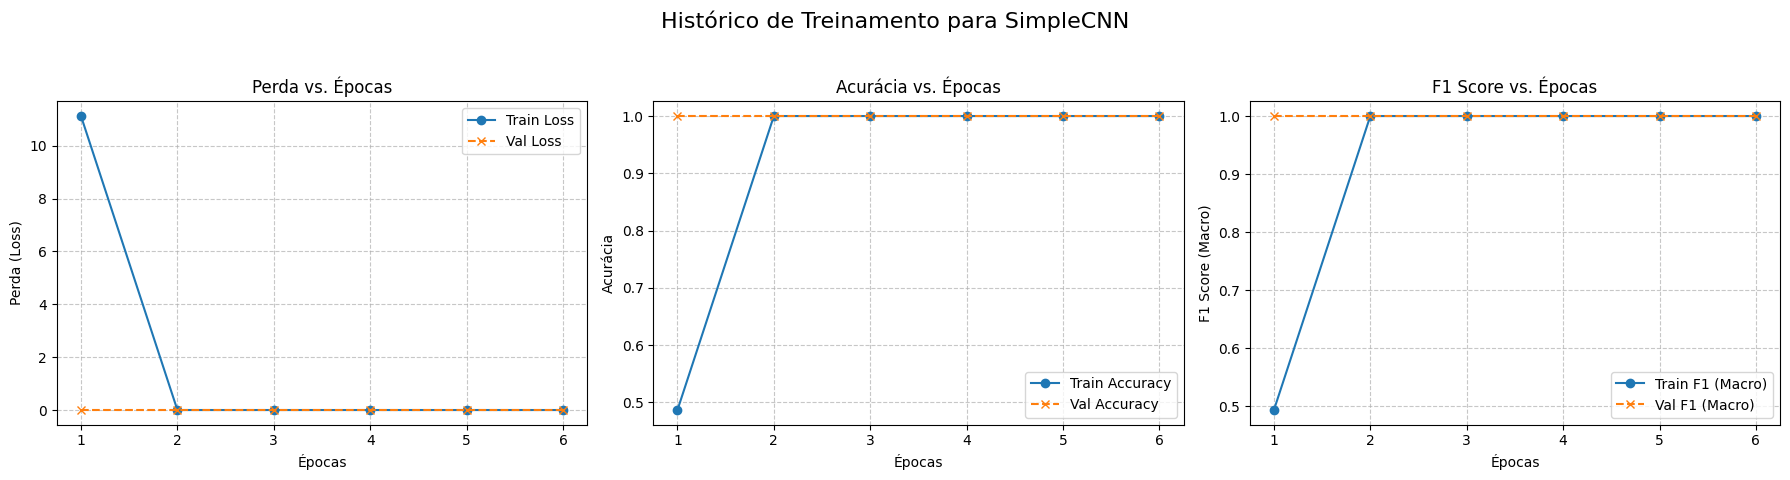


--- Avaliando Modelo: SimpleCNN no Conjunto de Teste ---


SimpleCNN - Resultados do Teste:
  Loss: 0.0000
  Accuracy (Macro): 1.0000
  F1-Score (Macro): 1.0000
  Precision (Macro): 1.0000
  Recall (Macro): 1.0000


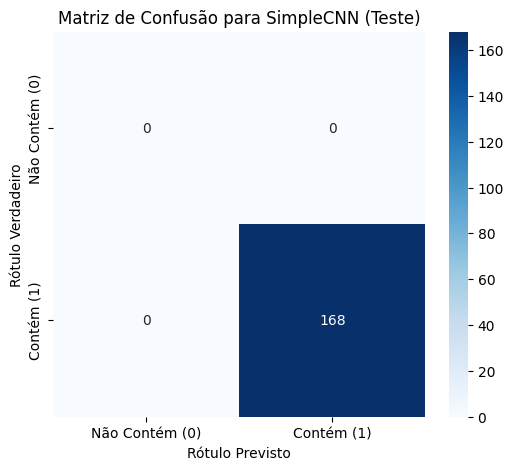

In [ ]:
print("\n--- Custom Model 1: SimpleCNN ---")
model_c1_name = "SimpleCNN"

if train_loader and val_loader:
    model_c1 = SimpleCNN(num_classes=NUM_CLASSES).to(device)
    optimizer_c1 = optim.Adam(model_c1.parameters(), lr=LEARNING_RATE)
    scheduler_c1 = ReduceLROnPlateau(optimizer_c1, mode='min', factor=0.1, patience=PATIENCE-2, verbose=True)

    model_c1, history_c1 = train_model_pipeline(
        model_c1, model_c1_name, train_loader, val_loader,
        criterion, optimizer_c1, scheduler_c1,
        num_epochs=NUM_EPOCHS, patience=PATIENCE, device=device
    )
    plot_training_history(history_c1, model_c1_name)
    
    if test_loader:
        acc_c1, f1_c1, prec_c1, rec_c1, cm_c1 = evaluate_model_on_test(
            model_c1, model_c1_name, test_loader, criterion, device
        )
        all_model_results[model_c1_name] = {'accuracy': acc_c1, 'f1_macro': f1_c1,
                                            'precision_macro': prec_c1, 'recall_macro': rec_c1,
                                            'cm': cm_c1, 'history': history_c1}
    else:
        print(f"AVISO: test_loader não disponível. Não foi possível avaliar {model_c1_name} no conjunto de teste.")
else:
    print(f"AVISO: train_loader ou val_loader não disponíveis. Treinamento do {model_c1_name} abortado.")


--- Custom Model 2: ModerateCNN ---

--- Iniciando Treinamento para o Modelo: ModerateCNN ---


Epoch 1/15 | LR: 1.0e-04 | Train Loss: 6.2974, Acc: 0.4937, F1: 0.4968 | Val Loss: 0.0000, Acc: 1.0000, F1: 1.0000
Perda de validação (0.0000) melhorou. Modelo salvo em 'ModerateCNN_best.pth'.


Epoch 2/15 | LR: 1.0e-04 | Train Loss: 0.0000, Acc: 1.0000, F1: 1.0000 | Val Loss: 0.0000, Acc: 1.0000, F1: 1.0000
Perda de validação não melhorou por 1 épocas.


Epoch 3/15 | LR: 1.0e-04 | Train Loss: 0.0000, Acc: 1.0000, F1: 1.0000 | Val Loss: 0.0000, Acc: 1.0000, F1: 1.0000
Perda de validação não melhorou por 2 épocas.


Epoch 4/15 | LR: 1.0e-04 | Train Loss: 0.0000, Acc: 1.0000, F1: 1.0000 | Val Loss: 0.0000, Acc: 1.0000, F1: 1.0000
Perda de validação não melhorou por 3 épocas.


Epoch 5/15 | LR: 1.0e-04 | Train Loss: 0.0000, Acc: 1.0000, F1: 1.0000 | Val Loss: 0.0000, Acc: 1.0000, F1: 1.0000
Perda de validação não melhorou por 4 épocas.


C:\Users\rseit\AppData\Local\Temp\ipykernel_21508\2751842797.py:148: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_final_path))


Epoch 6/15 | LR: 1.0e-05 | Train Loss: 0.0000, Acc: 1.0000, F1: 1.0000 | Val Loss: 0.0000, Acc: 1.0000, F1: 1.0000
Perda de validação não melhorou por 5 épocas.
Parada antecipada (Early Stopping) acionada após 6 épocas.
--- Treinamento Concluído para ModerateCNN ---
Melhor modelo 'ModerateCNN_best.pth' carregado para avaliação final.


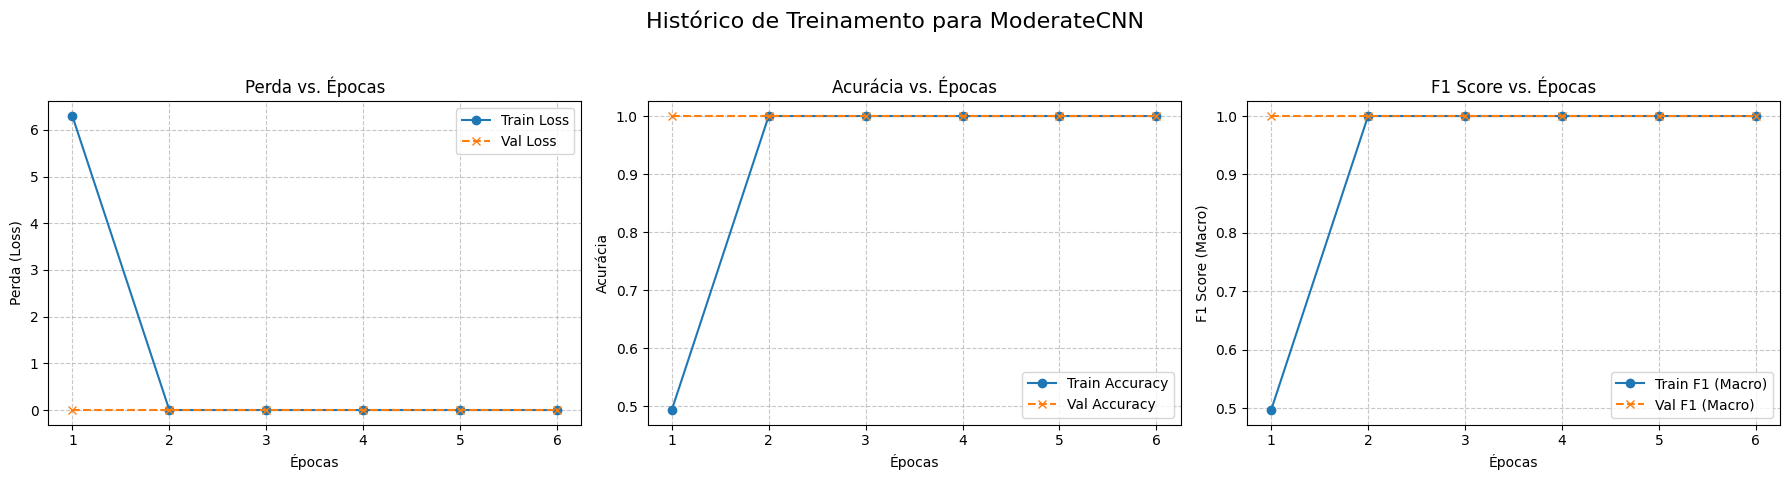


--- Avaliando Modelo: ModerateCNN no Conjunto de Teste ---


ModerateCNN - Resultados do Teste:
  Loss: 0.0000
  Accuracy (Macro): 1.0000
  F1-Score (Macro): 1.0000
  Precision (Macro): 1.0000
  Recall (Macro): 1.0000


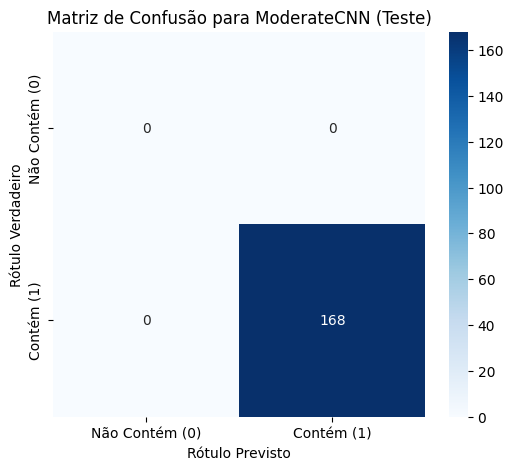

In [ ]:
print("\n--- Custom Model 2: ModerateCNN ---")
model_c2_name = "ModerateCNN"

if train_loader and val_loader:
    model_c2 = ModerateCNN(num_classes=NUM_CLASSES).to(device)
    optimizer_c2 = optim.Adam(model_c2.parameters(), lr=LEARNING_RATE)
    scheduler_c2 = ReduceLROnPlateau(optimizer_c2, mode='min', factor=0.1, patience=PATIENCE-2, verbose=True)

    model_c2, history_c2 = train_model_pipeline(
        model_c2, model_c2_name, train_loader, val_loader,
        criterion, optimizer_c2, scheduler_c2,
        num_epochs=NUM_EPOCHS, patience=PATIENCE, device=device
    )
    plot_training_history(history_c2, model_c2_name)

    if test_loader:
        acc_c2, f1_c2, prec_c2, rec_c2, cm_c2 = evaluate_model_on_test(
            model_c2, model_c2_name, test_loader, criterion, device
        )
        all_model_results[model_c2_name] = {'accuracy': acc_c2, 'f1_macro': f1_c2,
                                            'precision_macro': prec_c2, 'recall_macro': rec_c2,
                                            'cm': cm_c2, 'history': history_c2}
    else:
        print(f"AVISO: test_loader não disponível. Não foi possível avaliar {model_c2_name} no conjunto de teste.")
else:
    print(f"AVISO: train_loader ou val_loader não disponíveis. Treinamento do {model_c2_name} abortado.")


--- Custom Model 3: AdvancedCNN ---

--- Iniciando Treinamento para o Modelo: AdvancedCNN_Small ---


Epoch 1/15 | LR: 1.0e-04 | Train Loss: 0.0175, Acc: 0.4976, F1: 0.4988 | Val Loss: 0.0000, Acc: 1.0000, F1: 1.0000
Perda de validação (0.0000) melhorou. Modelo salvo em 'AdvancedCNN_Small_best.pth'.


Epoch 2/15 | LR: 1.0e-04 | Train Loss: 0.0000, Acc: 1.0000, F1: 1.0000 | Val Loss: 0.0000, Acc: 1.0000, F1: 1.0000
Perda de validação não melhorou por 1 épocas.


Epoch 3/15 | LR: 1.0e-04 | Train Loss: 0.0000, Acc: 1.0000, F1: 1.0000 | Val Loss: 0.0000, Acc: 1.0000, F1: 1.0000
Perda de validação não melhorou por 2 épocas.


Epoch 4/15 | LR: 1.0e-04 | Train Loss: 0.0000, Acc: 1.0000, F1: 1.0000 | Val Loss: 0.0000, Acc: 1.0000, F1: 1.0000
Perda de validação não melhorou por 3 épocas.


Epoch 5/15 | LR: 1.0e-04 | Train Loss: 0.0000, Acc: 1.0000, F1: 1.0000 | Val Loss: 0.0000, Acc: 1.0000, F1: 1.0000
Perda de validação não melhorou por 4 épocas.


C:\Users\rseit\AppData\Local\Temp\ipykernel_21508\2751842797.py:148: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_final_path))


Epoch 6/15 | LR: 1.0e-05 | Train Loss: 0.0000, Acc: 1.0000, F1: 1.0000 | Val Loss: 0.0000, Acc: 1.0000, F1: 1.0000
Perda de validação não melhorou por 5 épocas.
Parada antecipada (Early Stopping) acionada após 6 épocas.
--- Treinamento Concluído para AdvancedCNN_Small ---
Melhor modelo 'AdvancedCNN_Small_best.pth' carregado para avaliação final.


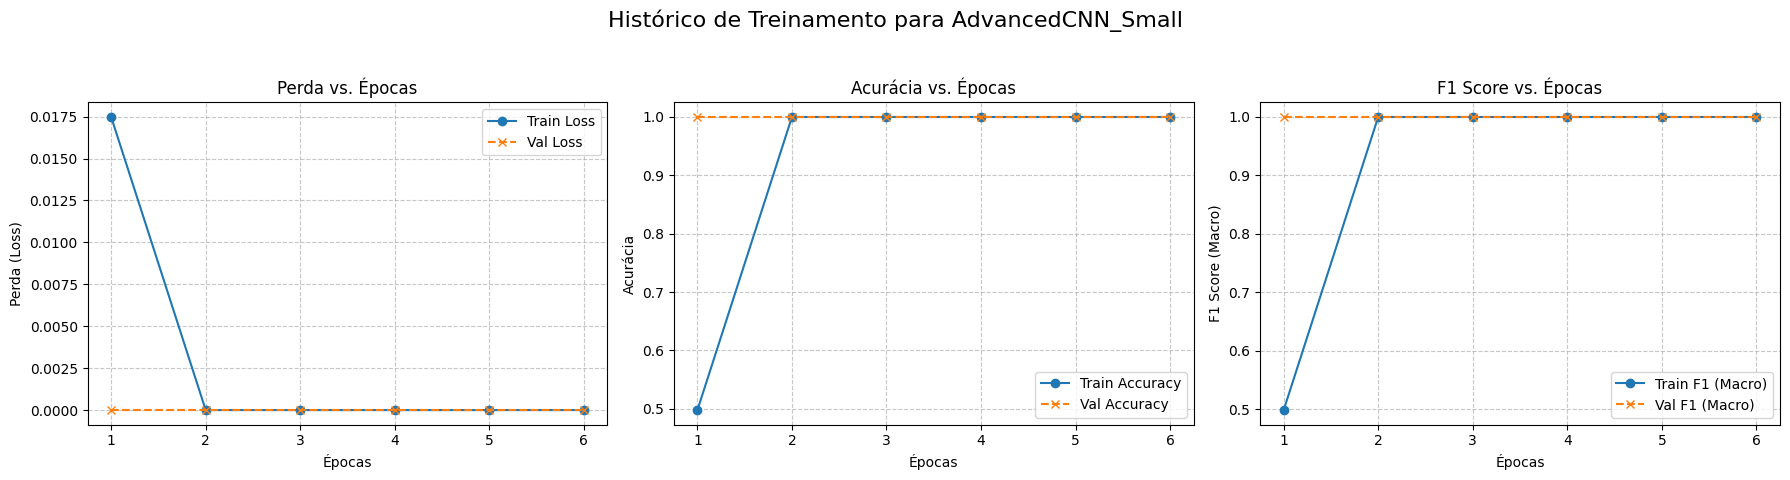


--- Avaliando Modelo: AdvancedCNN_Small no Conjunto de Teste ---


AdvancedCNN_Small - Resultados do Teste:
  Loss: 0.0000
  Accuracy (Macro): 1.0000
  F1-Score (Macro): 1.0000
  Precision (Macro): 1.0000
  Recall (Macro): 1.0000


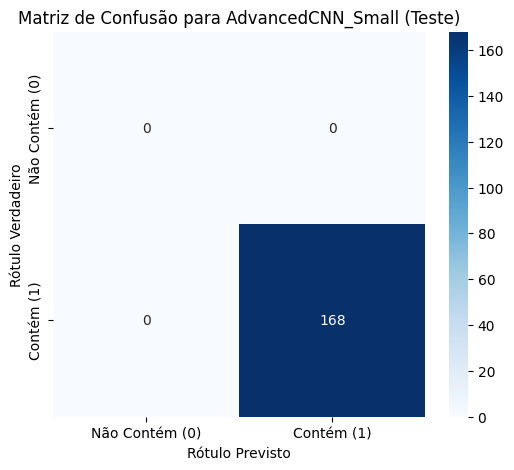

In [ ]:
print("\n--- Custom Model 3: AdvancedCNN ---")
model_c3_name = "AdvancedCNN_Small"

if train_loader and val_loader:
    model_c3 = get_advanced_cnn_small(num_classes=NUM_CLASSES).to(device)
    optimizer_c3 = optim.Adam(model_c3.parameters(), lr=LEARNING_RATE)
    scheduler_c3 = ReduceLROnPlateau(optimizer_c3, mode='min', factor=0.1, patience=PATIENCE-2, verbose=True)

    model_c3, history_c3 = train_model_pipeline(
        model_c3, model_c3_name, train_loader, val_loader,
        criterion, optimizer_c3, scheduler_c3,
        num_epochs=NUM_EPOCHS, patience=PATIENCE, device=device
    )
    plot_training_history(history_c3, model_c3_name)

    if test_loader:
        acc_c3, f1_c3, prec_c3, rec_c3, cm_c3 = evaluate_model_on_test(
            model_c3, model_c3_name, test_loader, criterion, device
        )
        all_model_results[model_c3_name] = {'accuracy': acc_c3, 'f1_macro': f1_c3,
                                            'precision_macro': prec_c3, 'recall_macro': rec_c3,
                                            'cm': cm_c3, 'history': history_c3}
    else:
        print(f"AVISO: test_loader não disponível. Não foi possível avaliar {model_c3_name} no conjunto de teste.")
else:
    print(f"AVISO: train_loader ou val_loader não disponíveis. Treinamento do {model_c3_name} abortado.")


--- Comparação Geral do Desempenho dos Modelos (Conjunto de Teste) ---
           Modelo  Acurácia (Macro)  F1-Score (Macro)  Precisão (Macro)  Recall (Macro)
ResNet50_Baseline               1.0               1.0               1.0             1.0
        SimpleCNN               1.0               1.0               1.0             1.0
      ModerateCNN               1.0               1.0               1.0             1.0
AdvancedCNN_Small               1.0               1.0               1.0             1.0


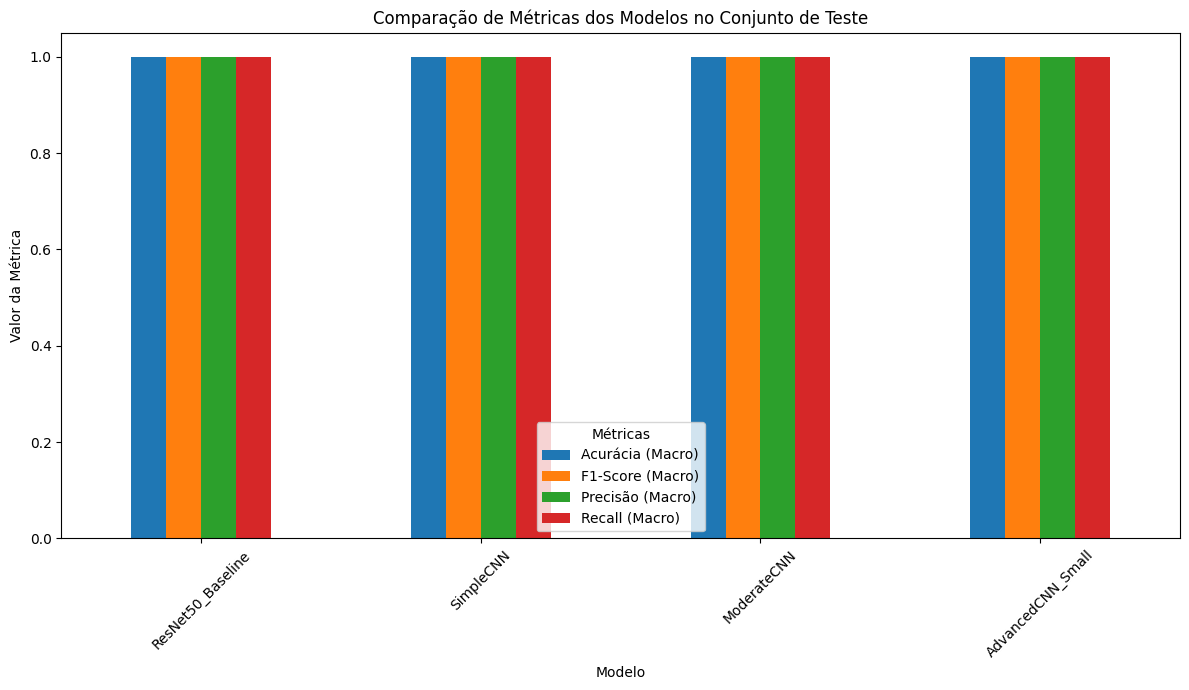

In [ ]:
print("\n--- Comparação Geral do Desempenho dos Modelos (Conjunto de Teste) ---")

results_list = []
for model_name, metrics in all_model_results.items():
    if metrics.get('accuracy') is not None:
        results_list.append({
            'Modelo': model_name,
            'Acurácia (Macro)': metrics['accuracy'],
            'F1-Score (Macro)': metrics['f1_macro'],
            'Precisão (Macro)': metrics['precision_macro'],
            'Recall (Macro)': metrics['recall_macro']
        })

if results_list:
    results_summary_df = pd.DataFrame(results_list)
    print(results_summary_df.to_string(index=False))
else:
    print("Nenhum resultado de avaliação disponível para resumir.")

if results_list:
    results_summary_df.set_index('Modelo').plot(kind='bar', figsize=(12, 7), rot=45)
    plt.title('Comparação de Métricas dos Modelos no Conjunto de Teste')
    plt.ylabel('Valor da Métrica')
    plt.legend(title='Métricas')
    plt.tight_layout()
    plt.show()

In [ ]:
pip install torchcam

   ---------------------------------------- 0.0/46.0 kB ? eta -:--:--
   -------------------------- ------------- 30.7/46.0 kB ? eta -:--:--
   ---------------------------------------- 46.0/46.0 kB 1.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
model_c3 = get_advanced_cnn_small(num_classes=NUM_CLASSES).to(device)

In [ ]:
from pathlib import Path

MODEL_SAVE_PATH = Path('./saved_models_revised')
nome_arquivo_pesos = 'AdvancedCNN_Small_best.pth'
caminho_completo_pesos = MODEL_SAVE_PATH / nome_arquivo_pesos

if caminho_completo_pesos.exists():
    try:
        model_c3.load_state_dict(torch.load(caminho_completo_pesos, map_location=device))
        print(f"Pesos de '{nome_arquivo_pesos}' carregados com sucesso em model_c3.")
        model_c3.eval()
    except Exception as e:
        print(f"Erro ao carregar os pesos de '{nome_arquivo_pesos}': {e}")
        print("Verifique se a arquitetura do modelo instanciado corresponde exatamente à arquitetura usada quando os pesos foram salvos.")
else:
    print(f"ERRO: Arquivo de pesos '{nome_arquivo_pesos}' não encontrado em '{MODEL_SAVE_PATH}'.")
    print("Você precisará treinar o modelo novamente se não conseguir localizar este arquivo.")

Pesos de 'AdvancedCNN_Small_best.pth' carregados com sucesso em model_c3.


C:\Users\rseit\AppData\Local\Temp\ipykernel_25656\3219386728.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_c3.load_state_dict(torch.load(caminho_completo_pesos,

In [ ]:
print(f"\n--- Definindo e Carregando Modelo 'AdvancedCNN_Small' (model_c3) ---")
def init_weights_he(m):
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += identity
        out = self.relu(out)
        return out

class AdvancedCNN(nn.Module):
    def __init__(self, block_class, num_blocks_list, num_classes=NUM_CLASSES, init_channels=64):
        super(AdvancedCNN, self).__init__()
        self.in_channels = init_channels
        self.initial_conv = nn.Sequential(
            nn.Conv2d(3, self.in_channels, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(self.in_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        self.layer1 = self._make_layer(block_class, init_channels, num_blocks_list[0], stride=1)
        self.layer2 = self._make_layer(block_class, init_channels*2, num_blocks_list[1], stride=2)
        self.layer3 = self._make_layer(block_class, init_channels*4, num_blocks_list[2], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(init_channels*4, num_classes)
        self.apply(init_weights_he)

    def _make_layer(self, block_class, out_channels_for_block, num_blocks_in_layer, stride):
        strides = [stride] + [1]*(num_blocks_in_layer-1)
        layers = []
        for s in strides:
            layers.append(block_class(self.in_channels, out_channels_for_block, s))
            self.in_channels = out_channels_for_block
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.initial_conv(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

def get_advanced_cnn_small(num_classes=NUM_CLASSES):
    if 'NUM_CLASSES' not in globals():
        raise NameError("NUM_CLASSES não está definido. Defina-o antes de chamar get_advanced_cnn_small.")
    return AdvancedCNN(ResidualBlock, [2, 2, 2], num_classes=num_classes, init_channels=64)

print("Arquiteturas para AdvancedCNN (model_c3) definidas.")

if 'device' not in globals() or 'NUM_CLASSES' not in globals():
    print("ERRO: 'device' ou 'NUM_CLASSES' não estão definidos. Não é possível instanciar o modelo.")
else:
    model_c3 = get_advanced_cnn_small(num_classes=NUM_CLASSES).to(device)
    model_c3_name = "AdvancedCNN_Small"
    print(f"Modelo '{model_c3_name}' instanciado e movido para '{device}'.")

    if 'MODEL_SAVE_PATH' not in globals():
        MODEL_SAVE_PATH = Path('./saved_models_revised') 
        print(f"AVISO: MODEL_SAVE_PATH não definido, usando padrão: {MODEL_SAVE_PATH}")
        if not MODEL_SAVE_PATH.exists():
            os.makedirs(MODEL_SAVE_PATH)

    nome_arquivo_pesos_c3 = f'{model_c3_name}_best.pth'
    caminho_completo_pesos_c3 = MODEL_SAVE_PATH / nome_arquivo_pesos_c3

    if caminho_completo_pesos_c3.exists():
        try:
            model_c3.load_state_dict(torch.load(caminho_completo_pesos_c3, map_location=device))
            print(f"Pesos de '{nome_arquivo_pesos_c3}' carregados com sucesso em '{model_c3_name}'.")
            model_c3.eval()
        except Exception as e:
            print(f"ERRO ao carregar os pesos para '{model_c3_name}' de '{nome_arquivo_pesos_c3}': {e}")
            print("Verifique o caminho do arquivo e se a arquitetura do modelo corresponde aos pesos salvos.")
    else:
        print(f"ERRO CRÍTICO: Arquivo de pesos '{nome_arquivo_pesos_c3}' NÃO ENCONTRADO em '{MODEL_SAVE_PATH.resolve()}'.")
        print(f"Você não poderá usar o modelo '{model_c3_name}' treinado para o Grad-CAM sem este arquivo.")
        print("Considere treinar o modelo novamente se o arquivo de pesos não puder ser localizado.")


--- Definindo e Carregando Modelo 'AdvancedCNN_Small' (model_c3) ---
Arquiteturas para AdvancedCNN (model_c3) definidas.
Modelo 'AdvancedCNN_Small' instanciado e movido para 'cpu'.
Pesos de 'AdvancedCNN_Small_best.pth' carregados com sucesso em 'AdvancedCNN_Small'.


C:\Users\rseit\AppData\Local\Temp\ipykernel_25656\2423819875.py:128: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_c3.load_state_dict(torch.load(caminho_completo_pesos

In [ ]:
print("Verificando variáveis para Grad-CAM...")

if 'modelo_para_gradcam' in globals() and modelo_para_gradcam is not None:
    print(f"  modelo_para_gradcam: DEFINIDO (tipo: {type(modelo_para_gradcam).__name__})")
else:
    print("  modelo_para_gradcam: NÃO DEFINIDO ou é None")

if 'nome_modelo_gradcam' in globals() and nome_modelo_gradcam:
    print(f"  nome_modelo_gradcam: DEFINIDO (valor: '{nome_modelo_gradcam}')")
else:
    print("  nome_modelo_gradcam: NÃO DEFINIDO ou vazio")

if 'test_loader' in globals() and test_loader is not None:
    print(f"  test_loader: DEFINIDO (tipo: {type(test_loader).__name__})")
    if hasattr(test_loader, 'dataset'):
         print(f"    test_loader contém {len(test_loader.dataset)} amostras.")
else:
    print("  test_loader: NÃO DEFINIDO ou é None")

if 'device' in globals() and device is not None:
    print(f"  device: DEFINIDO (valor: {device})")
else:
    print("  device: NÃO DEFINIDO ou é None")

Verificando variáveis para Grad-CAM...
  modelo_para_gradcam: DEFINIDO (tipo: AdvancedCNN)
  nome_modelo_gradcam: DEFINIDO (valor: 'AdvancedCNN_Small')
  test_loader: DEFINIDO (tipo: DataLoader)
    test_loader contém 168 amostras.
  device: DEFINIDO (valor: cpu)



--- Implementando Grad-CAM (Geração Individual de CAMs) ---
Usando camada alvo para Grad-CAM em 'AdvancedCNN_Small': Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)


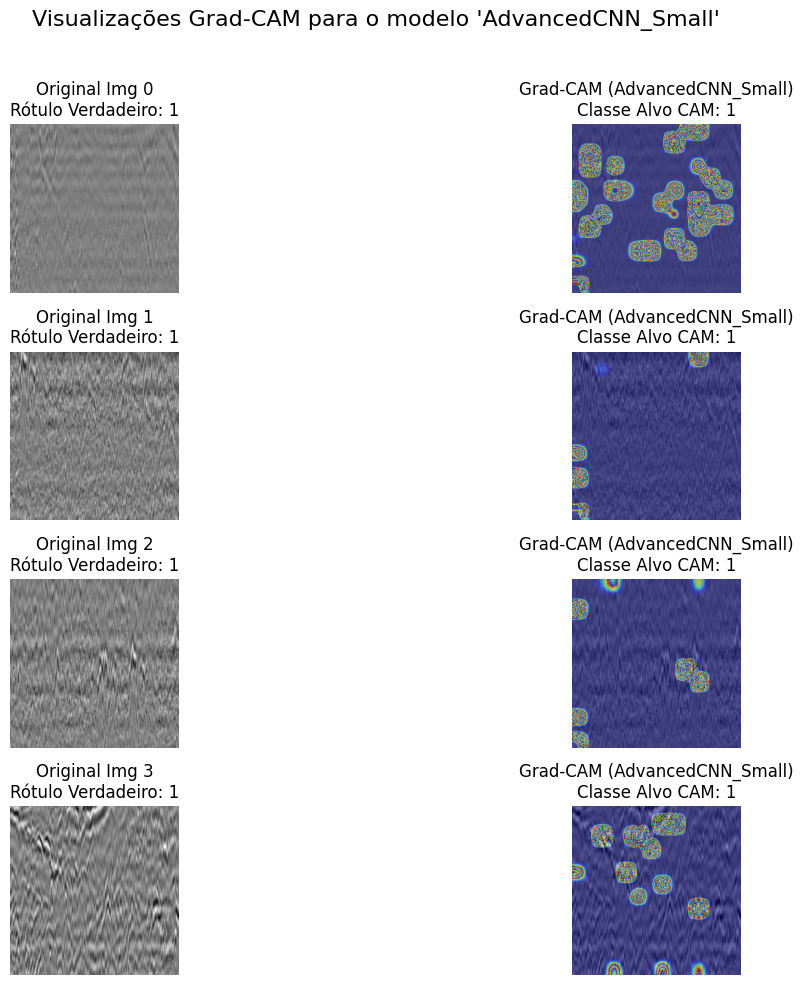

In [ ]:
if 'modelo_para_gradcam' not in globals() or modelo_para_gradcam is None:
    print("ERRO: 'modelo_para_gradcam' não está definido. Carregue o modelo treinado primeiro.")

elif 'nome_modelo_gradcam' not in globals() or not nome_modelo_gradcam:
     print("ERRO: 'nome_modelo_gradcam' não está definido. Defina o nome do modelo (string).")
     modelo_para_gradcam = None
elif 'test_loader' not in globals() or test_loader is None:
    print("ERRO: 'test_loader' não está definido.")
    modelo_para_gradcam = None
elif 'device' not in globals():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"AVISO: 'device' não definido globalmente, usando: {device}")
if 'IMG_SIZE' not in globals():
    IMG_SIZE = 224

print("\n--- Implementando Grad-CAM (Geração Individual de CAMs) ---")

if modelo_para_gradcam and nome_modelo_gradcam and test_loader and device:
    modelo_para_gradcam.eval()

    for param in modelo_para_gradcam.parameters():
        param.requires_grad_(True)

    camada_alvo_gradcam = None
    if nome_modelo_gradcam == "ResNet50_Baseline":
        camada_alvo_gradcam = modelo_para_gradcam.layer4[-1]
    elif nome_modelo_gradcam == "SimpleCNN":
        camada_alvo_gradcam = modelo_para_gradcam.conv_block2[0] 
    elif nome_modelo_gradcam == "ModerateCNN":
        camada_alvo_gradcam = modelo_para_gradcam.features[15] 
    elif nome_modelo_gradcam == "AdvancedCNN_Small":
        camada_alvo_gradcam = modelo_para_gradcam.layer3[-1].conv2
    
    cam_extractor = None
    if camada_alvo_gradcam is not None:
        print(f"Usando camada alvo para Grad-CAM em '{nome_modelo_gradcam}': {camada_alvo_gradcam}")
        try:
            cam_extractor = GradCAM(modelo_para_gradcam, target_layer=camada_alvo_gradcam)
        except Exception as e_explicit:
            print(f"ERRO ao instanciar GradCAM com camada alvo explícita: {e_explicit}.")
            print("Tentando sem especificar a camada alvo...")
            try:
                cam_extractor = GradCAM(modelo_para_gradcam)
                print("GradCAM instanciado sem camada alvo explícita (Torchcam tentará inferir).")
            except Exception as e_infer_fallback:
                print(f"ERRO FATAL ao instanciar GradCAM (fallback): {e_infer_fallback}.")
    else:
        print(f"AVISO: Camada alvo para Grad-CAM não identificada para '{nome_modelo_gradcam}'. Tentando inferência automática.")
        try:
            cam_extractor = GradCAM(modelo_para_gradcam)
            print("GradCAM instanciado sem camada alvo explícita (Torchcam tentará inferir).")
        except Exception as e_infer_direct:
            print(f"ERRO FATAL ao instanciar GradCAM (inferência direta): {e_infer_direct}.")

    if cam_extractor:
        try:
            dataiter_test = iter(test_loader)
            images_test_gc, labels_test_gc = next(dataiter_test)
            
            num_imgs_gradcam = min(4, images_test_gc.size(0))
            if num_imgs_gradcam == 0:
                print("Nenhuma imagem no batch de teste para Grad-CAM.")
            else:
                images_to_analyze_batch = images_test_gc[:num_imgs_gradcam].to(device)
                labels_original_batch = labels_test_gc[:num_imgs_gradcam]

                inv_normalize = transforms.Normalize(
                    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
                    std=[1/0.229, 1/0.224, 1/0.225]
                )
                
                plt.figure(figsize=(15, 5 * num_imgs_gradcam / 2 if num_imgs_gradcam > 1 else 7))

                for i in range(num_imgs_gradcam):
                    current_image_tensor = images_to_analyze_batch[i].unsqueeze(0)
                    current_label_original = labels_original_batch[i]
                    

                    current_out_gc = modelo_para_gradcam(current_image_tensor)
                    
                    current_target_class_list = [1]

                    activation_map_list_for_current_image = cam_extractor(current_target_class_list, current_out_gc)
                    
                    if not activation_map_list_for_current_image:
                        print(f"ERRO: Nenhum mapa de ativação retornado para a imagem {i}.")
                        pil_img_orig = transforms.ToPILImage()(inv_normalize(images_to_analyze_batch[i].cpu()))
                        plt.subplot(num_imgs_gradcam, 2, 2 * i + 1)
                        plt.imshow(pil_img_orig)
                        plt.title(f"Original Img {i}\nRótulo: {current_label_original.item()} (CAM FALHOU)")
                        plt.axis('off')
                        plt.subplot(num_imgs_gradcam, 2, 2 * i + 2)
                        plt.imshow(pil_img_orig)
                        plt.title(f"Grad-CAM FALHOU para img {i}")
                        plt.axis('off')
                        continue

                    activation_map_single = activation_map_list_for_current_image[0] 
                    
                    img_tensor_normalized_for_plot = images_to_analyze_batch[i].cpu()
                    img_for_display = inv_normalize(img_tensor_normalized_for_plot)
                    pil_img = transforms.ToPILImage()(img_for_display)
                    
                    act_map_squeeze = activation_map_single.squeeze(0).cpu() if activation_map_single.ndim == 3 else activation_map_single.cpu()

                    try:
                        result_overlay = overlay_mask(pil_img, transforms.ToPILImage()(act_map_squeeze), alpha=0.5)
                    except Exception as e_overlay:
                        print(f"Erro ao criar overlay para imagem {i}: {e_overlay}")
                        result_overlay = pil_img

                    plt.subplot(num_imgs_gradcam, 2, 2 * i + 1)
                    plt.imshow(pil_img)
                    plt.title(f"Original Img {i}\nRótulo Verdadeiro: {current_label_original.item()}")
                    plt.axis('off')

                    plt.subplot(num_imgs_gradcam, 2, 2 * i + 2)
                    plt.imshow(result_overlay)
                    plt.title(f"Grad-CAM ({nome_modelo_gradcam})\nClasse Alvo CAM: {current_target_class_list[0]}")
                    plt.axis('off')
                
                plt.suptitle(f"Visualizações Grad-CAM para o modelo '{nome_modelo_gradcam}'", fontsize=16)
                plt.tight_layout(rect=[0, 0, 1, 0.96])
                plt.show()

                cam_extractor.remove_hooks()
        
        except StopIteration:
            print("Não foi possível obter um batch do test_loader para Grad-CAM. O loader pode estar vazio.")
        except Exception as e_main_gradcam:
            print(f"ERRO principal durante a execução do Grad-CAM: {e_main_gradcam}")
            import traceback
            traceback.print_exc()
            if 'cam_extractor' in locals() and cam_extractor is not None and hasattr(cam_extractor, 'remove_hooks'):
                cam_extractor.remove_hooks()
    elif modelo_para_gradcam and test_loader:
        print("Grad-CAM não pôde ser instanciado. Visualização abortada.")
else:
    print("AVISO: 'modelo_para_gradcam', 'nome_modelo_gradcam', 'test_loader' ou 'device' não estão devidamente definidos. Grad-CAM não será executado.")